In [1]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering, Statistics
# for Turing
using Turing,StatsPlots,PairPlots, CairoMakie

using Jens
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensModel as Jmodel
using Jens:LightModel as Jlight

using Jens.LensModel:NIEkappa as NIEkappa
using Jens.LightModel:SersicLight as SersicLight

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [2]:
xg, yg = LU.LensGrid(;xl=2., nx=51)

# Light Parameters
LightParaDict = Dict(:amp=>5., :Rsersic=>1., :n=>1, :varphi=>pi/3,
           :q=>0.5,:xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = SersicLight.SersicElliptical(xg, yg;
             LightParaDict...);

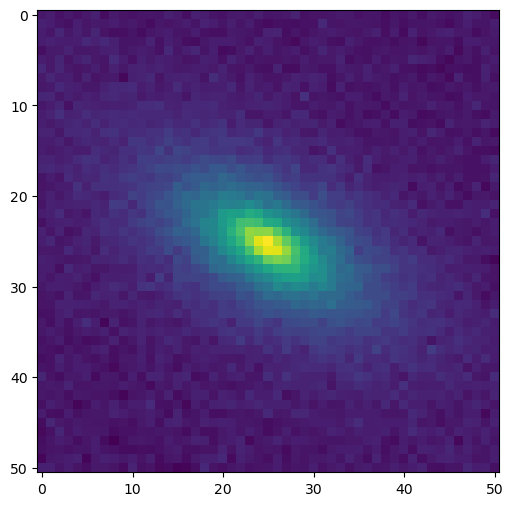

In [3]:
σ_noise = 0.5
data = SourceLight .+ rand(Normal(0, σ_noise), size(SourceLight))

FigLnes = PyPlot.figure(figsize=(6, 6))
L2 = plt.imshow(data)

gcf()

In [18]:
plt.clf()

In [12]:
@model function fit_source(x,y, data_obs)

    amp ~ truncated(Normal(5., 1.),lower=0, upper=10)
    Rsersic ~ truncated(Normal(1, 1),lower=0, upper=5)
    n ~ truncated(Normal(1, 1),lower=0.5, upper=10)
    varphi ~ truncated(Normal(pi/2, 1),lower=0,upper=6)
    q ~ truncated(Normal(0.5, 1),lower=0.01,upper=0.9)
    xcentre ~ truncated(Normal(0.1, 1),lower=-1, upper=1)
    ycentre ~ truncated(Normal(0.1, 1),lower=-1, upper=1)

    ParaDict = Dict(:amp=>amp, :Rsersic=>Rsersic, :n=>n, :varphi=>varphi,
           :q=>q,:xcentre=>xcentre, :ycentre=>ycentre)

    # adapt a normal noise
    σ_noise ~ truncated(Normal(1, 1), 0, 5)

    # set up model
    sourcelight = SersicLight.SersicElliptical(x, y; ParaDict...);


    # setup Likelihood
    for i in eachindex(data_obs)
        # only consider the value greater than background noise, s.t. noise = mean(data_obs)/5 here.
        if data_obs[i] > mean(data_obs)
            data_obs[i] ~ Normal(sourcelight[i], σ_noise)
        end
    end

end

fit_source (generic function with 2 methods)

In [13]:
chain = sample(fit_source(xg, yg, data),
         NUTS(400,0.65), 1000)#,  MCMCThreads(), 1000, 4)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 4.8828125e-5
└ @ Turing.Inference /Users/cyan/.julia/packages/Turing/9ylz5/src/mcmc/hmc.jl:207
Sampling   0%|▎                                         |  ETA: 0:18:38
Sampling   1%|▍                                         |  ETA: 0:09:25
Sampling   2%|▋                                         |  ETA: 0:06:18
Sampling   2%|▉                                         |  ETA: 0:04:44
Sampling   2%|█                                         |  ETA: 0:03:51
Sampling   3%|█▎                                        |  ETA: 0:03:14
Sampling   4%|█▌                                        |  ETA: 0:02:47
Sampling   4%|█▋                                        |  ETA: 0:02:27
Sampling   4%|█▉                                        |  ETA: 0:02:12
Sampling   5%|██▏                                       |  ETA: 0:02:00
Sampling   6%|██▎                                       |  ETA: 0:01:51
Sampl

Chains MCMC chain (1000×20×1 Array{Float64, 3}):

Iterations        = 401:1:1400
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 58.05 seconds
Compute duration  = 58.05 seconds
parameters        = amp, Rsersic, n, varphi, q, xcentre, ycentre, σ_noise
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

         amp    4.3191    0.0791    0.0041    363.4277   475.2209    1.0070    ⋯
     Rsersic    1.1019    0.0137    0.0007    346.9105   420.5765    1.0070    ⋯
           n    1.1102    0.0151    0.0008    391.4435   440.9532    1.0054    ⋯
      varphi    4.1922    0.0053    0.0001   1292.3532   571.3753    1.0013    ⋯
           q    0.4

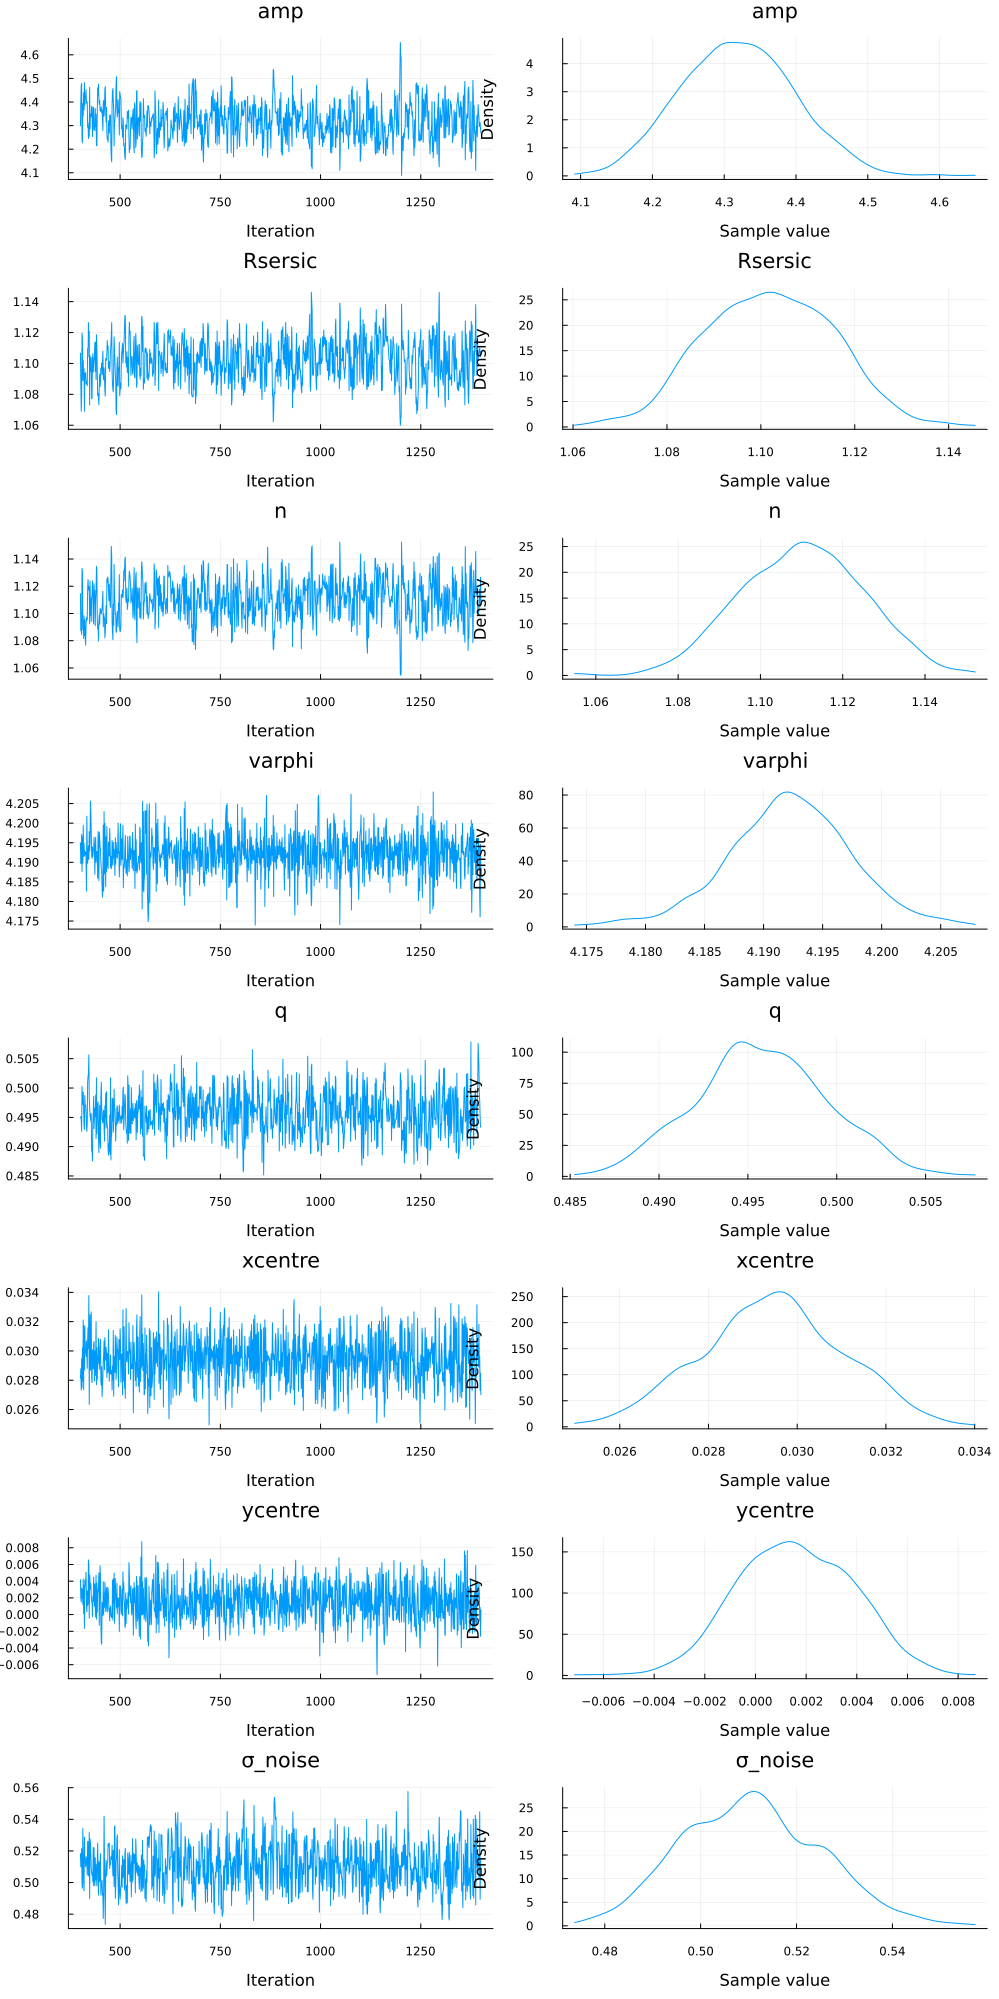

In [14]:
ChainPlot = StatsPlots.plot(chain)

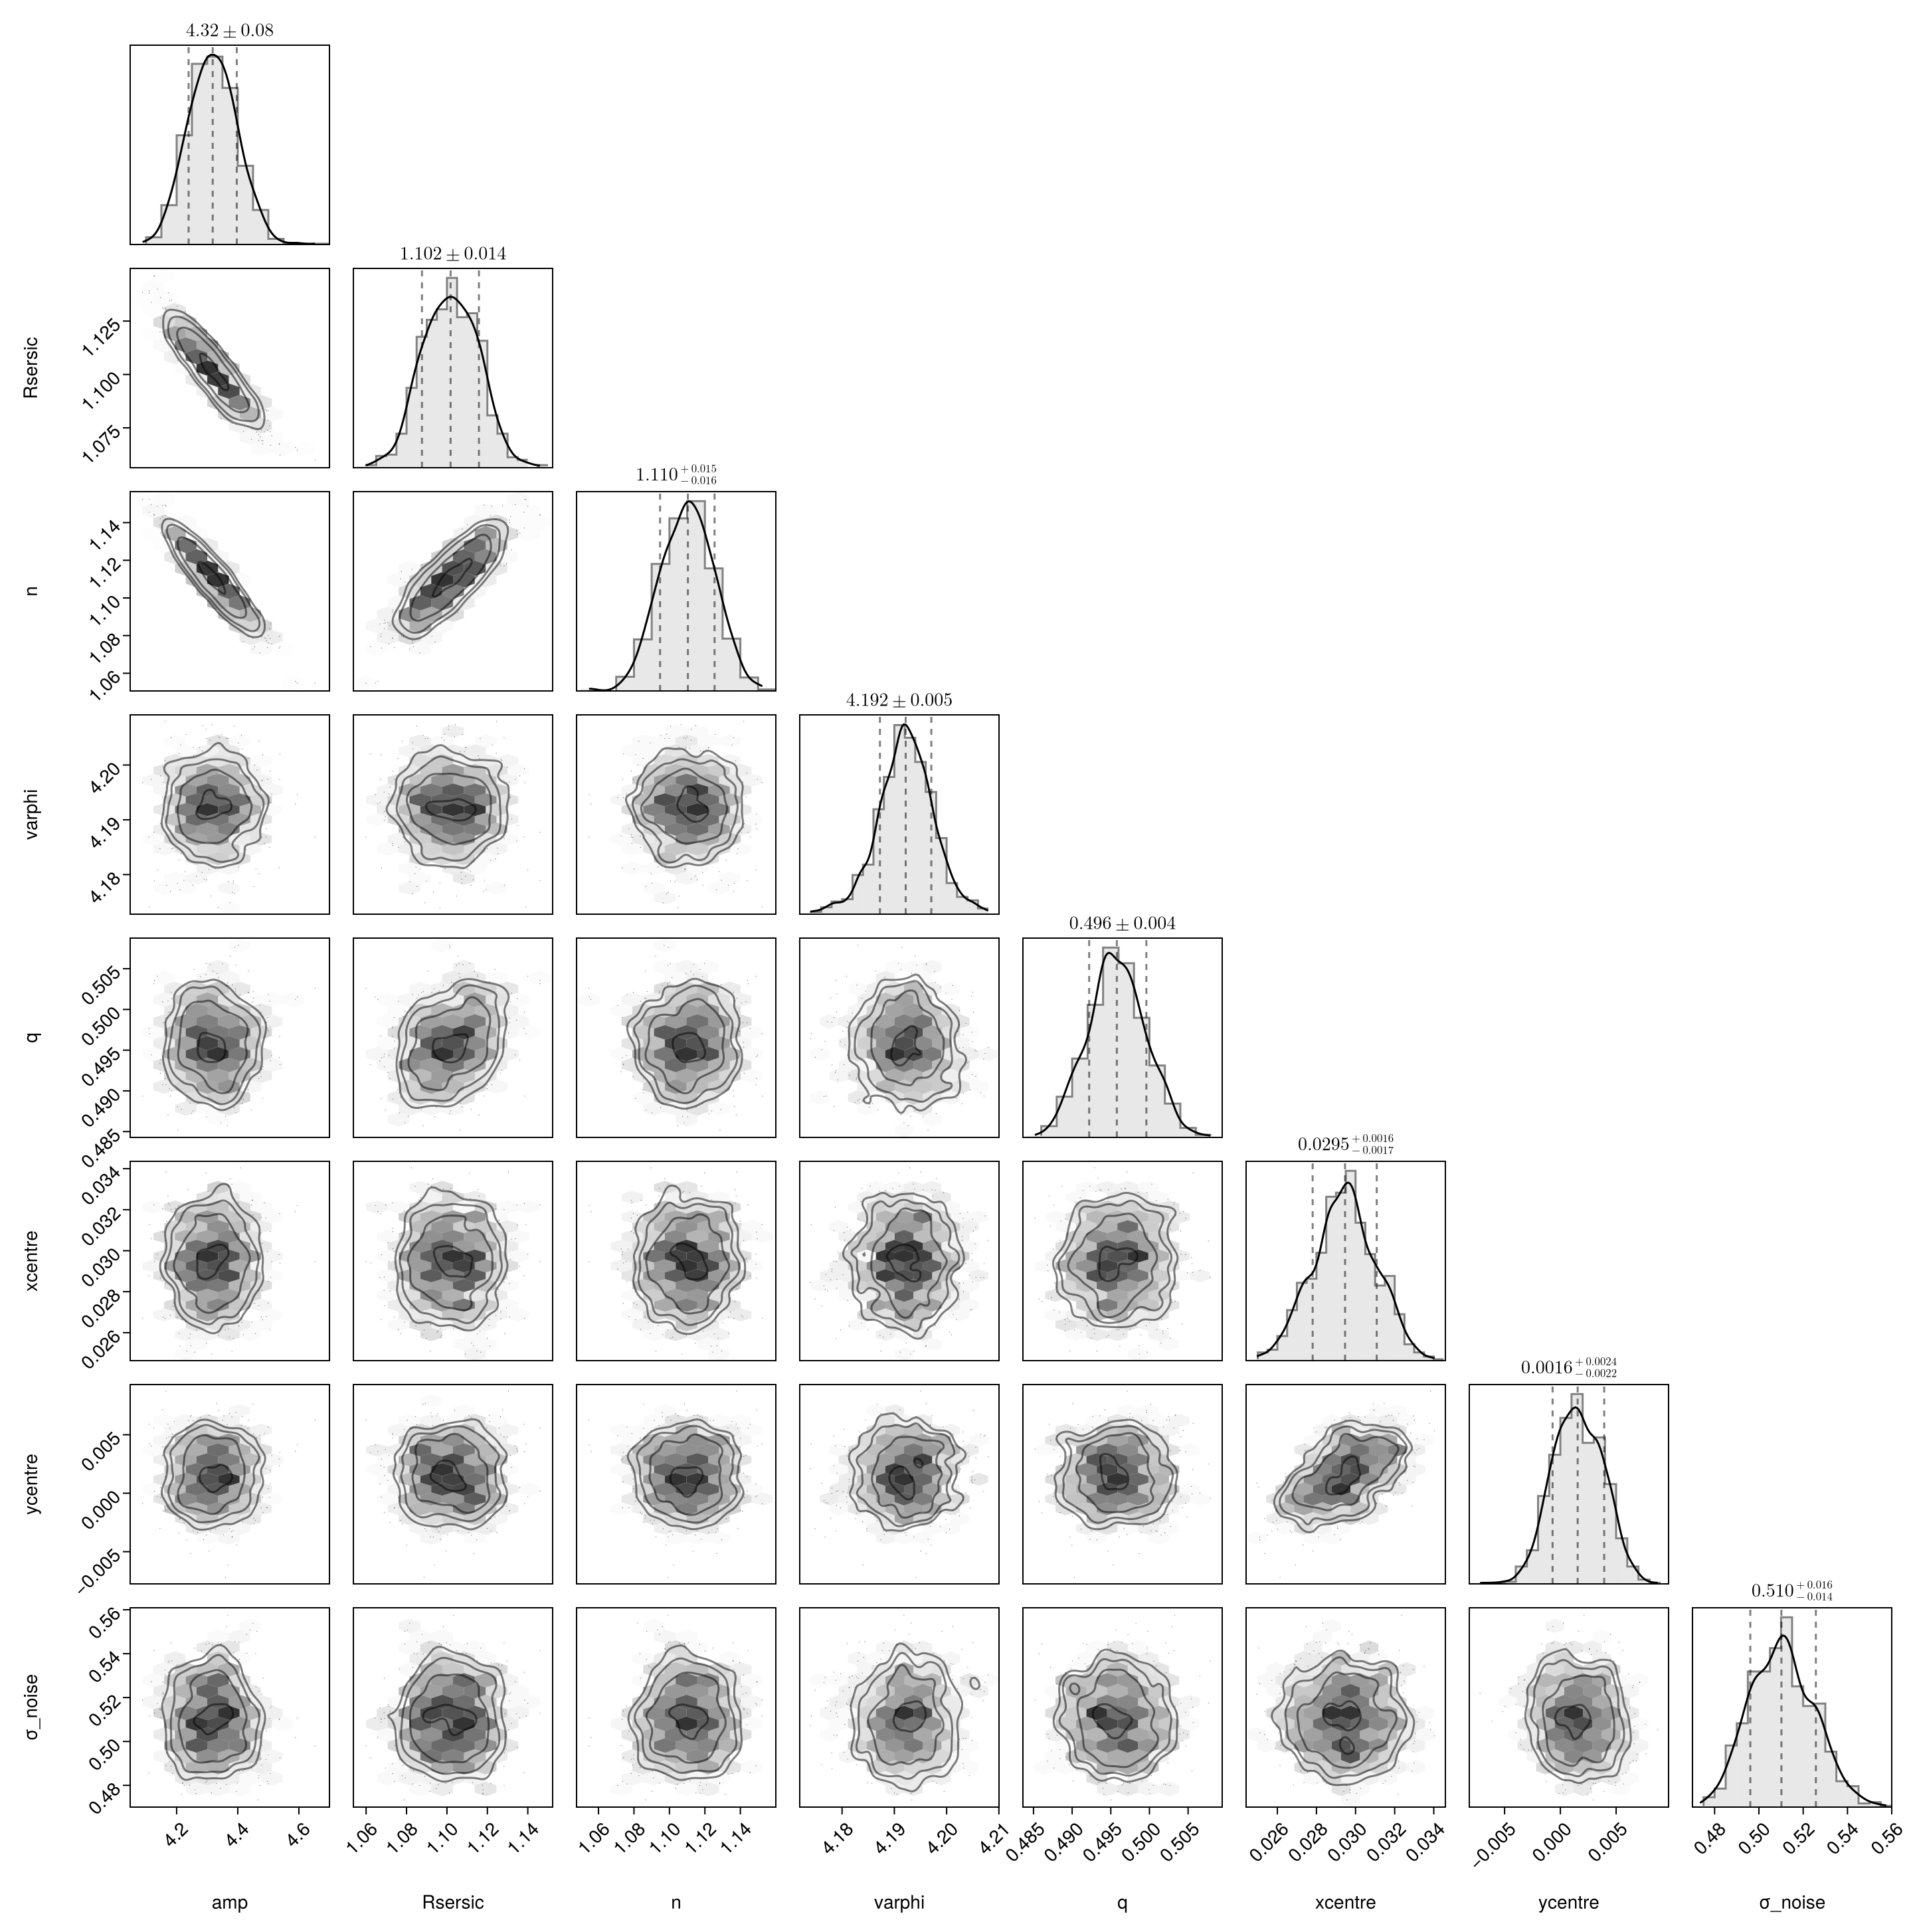

In [15]:
corner_fig = PairPlots.pairplot(chain)

In [16]:
mean_param = Dict([])
para_names = chain.name_map.parameters
for i in range(1,6)
    mean_param[para_names[i]] = mean(chain[:,i,1])
end

SourceLight = SersicLight.SersicElliptical(xg, yg;
             mean_param...);

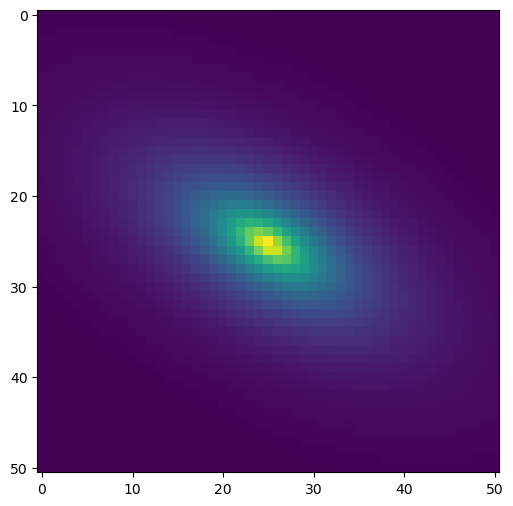

In [22]:
L3 = plt.imshow( SourceLight)
gcf()

In [24]:
plt.clf()

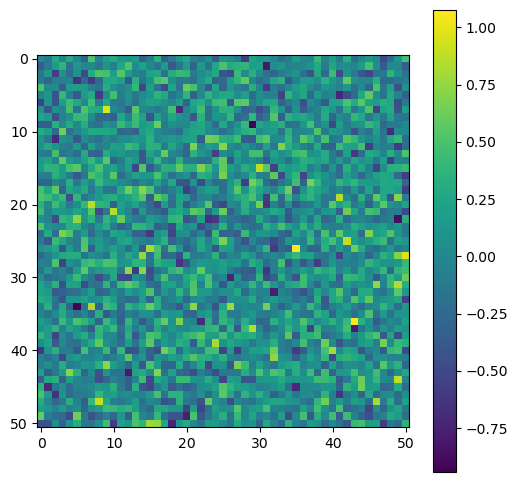

In [23]:
res = SourceLight - data
L4 = plt.imshow(res/mean(data))
plt.colorbar()
gcf()

In [25]:
plt.clf()